# Machine Learning Regression Pipeline for SFR Prediction

This notebook contains the complete, reproducible pipeline for predicting galaxy Star Formation Rates (SFR) using a CatBoost regressor, trained on the REGALADE catalog and cross-matched surveys.

## Computational Environment & Dependencies

To ensure reproducibility, this notebook specifies all fixed library versions used during development. The full dependency list is documented in the root directory's `requirements.txt`.

### Key Frameworks & Packages:
* **Python Version:** `3.10` or higher (recommended)
* **Gradient Boosting:** `catboost` (v1.2.x) — Main regression architecture
* **Data Science Stack:** `pandas`, `numpy`, `scipy` — Data cleaning, feature engineering, and statistical fits
* **Machine Learning:** `scikit-learn` — Dataset splitting (`train_test_split`) and Cross-Validation (`KFold`)
* **Visualization:** `matplotlib` — Hexbin density plots, residual distributions, and publication-ready figures

### Quick Environment Setup:
You can replicate this exact Python environment by running the following command in your terminal:
```bash
pip install -r requirements.txt

<>:178: SyntaxWarning: invalid escape sequence '\s'
<>:178: SyntaxWarning: invalid escape sequence '\e'
<>:178: SyntaxWarning: invalid escape sequence '\s'
<>:178: SyntaxWarning: invalid escape sequence '\e'
/var/folders/13/4k2sq35543lb3k4fbxwp7sj00000gn/T/ipykernel_18250/3237340007.py:178: SyntaxWarning: invalid escape sequence '\s'
  text_str = f"$\sigma$: {sigma:.3f}\n$\eta$: {eta:.3%}"
/var/folders/13/4k2sq35543lb3k4fbxwp7sj00000gn/T/ipykernel_18250/3237340007.py:178: SyntaxWarning: invalid escape sequence '\e'
  text_str = f"$\sigma$: {sigma:.3f}\n$\eta$: {eta:.3%}"


Start SFR Regression Pipeline

1. Loading and cleaning labeled dataset...
Valid samples after cleaning: 335064

2. Splitting dataset: 2/3 Train-Val set, 1/3 Blind Test set
Train-Val set size: 223376
Blind Test set size: 111688

3. Constructing features...
Total used features: 7 -> ['g-r', 'r-z', 'z-W1', 'W1-W2', 'redshift', 'gmag', 'logM']

4. Running 10-Fold Cross Validation (OOF)
   Fold 1/10 completed
   Fold 2/10 completed
   Fold 3/10 completed
   Fold 4/10 completed
   Fold 5/10 completed
   Fold 6/10 completed
   Fold 7/10 completed
   Fold 8/10 completed
   Fold 9/10 completed
   Fold 10/10 completed

Cross Validation (OOF) Results:
   R²     = 0.763
   RMSE   = 0.306 dex
   MAE    = 0.197 dex
   Bias   = -0.0001 dex
   σ      = 0.306 dex
   η (3σ) = 2.290%

Generating CV evaluation plots...


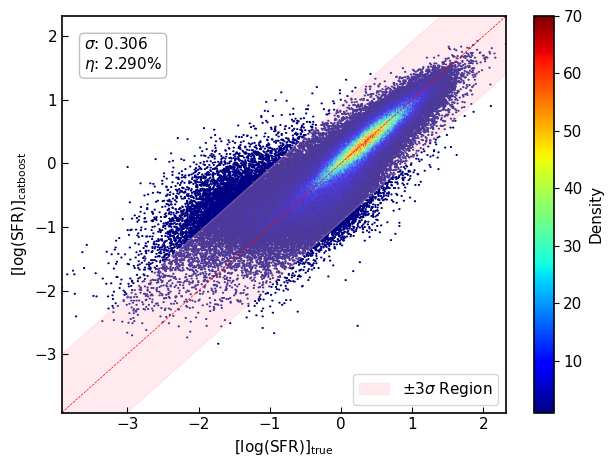

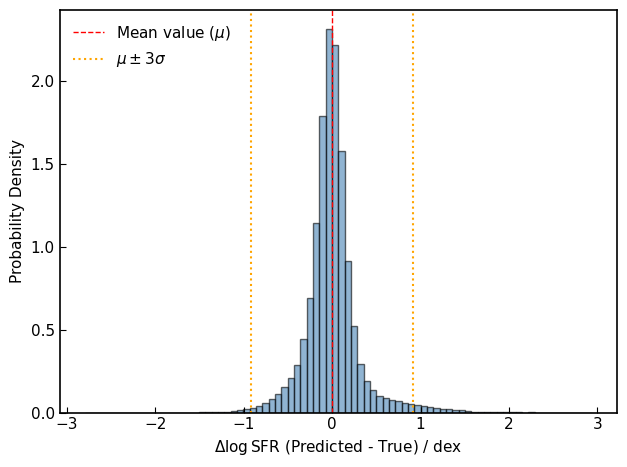


5. Training final CatBoost model on full Train-Val set
Final model training completed

6. Evaluating model on blind test set

Blind Test (Hold-out) Results:
   R²     = 0.760
   RMSE   = 0.306 dex
   MAE    = 0.196 dex
   Bias   = -0.0015 dex
   σ      = 0.306 dex
   η (3σ) = 2.302%

Blind test predictions saved to: /Users/cyh/Mass_SFR/newVersion/data/blind_test_predictions.csv

Generating blind test plots...


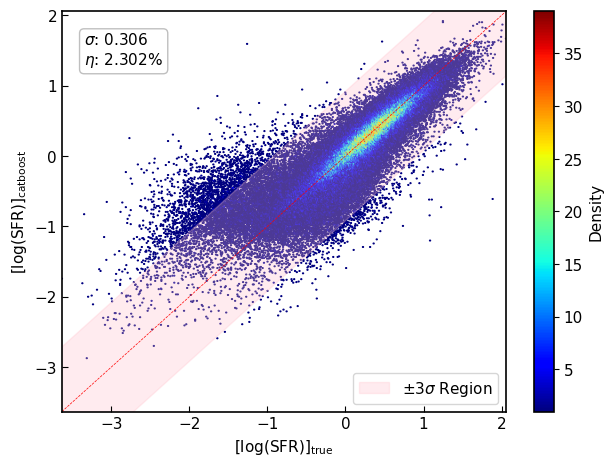

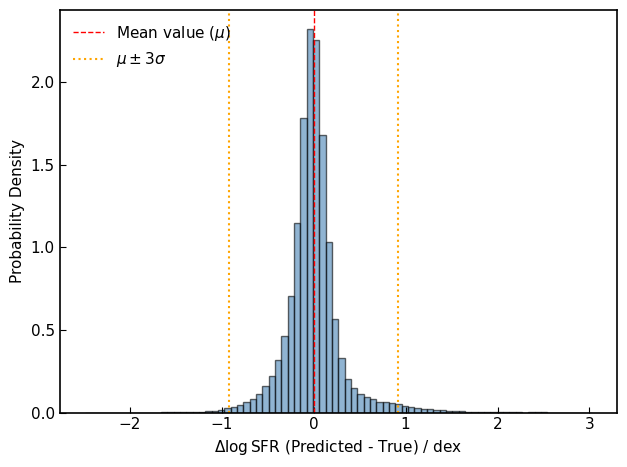

   All blind test plots saved successfully

7. Predicting external dataset...
External prediction completed and saved

All tasks finished! Total runtime: 124.47 seconds
Figures saved to: /Users/cyh/Mass_SFR/newVersion/Figure
Data results saved to: /Users/cyh/Mass_SFR/newVersion/data


In [5]:
# =====================================================================
# SFR Regression with CatBoost: Data Split, K-Fold CV, Training & Blind Test
# Workflow: Data Cleaning -> Train/Blind Split -> 10-Fold CV -> Model Training -> Validation
# =====================================================================
import os
import time
import warnings
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from catboost import CatBoostRegressor

# -------------------------- Global Configuration --------------------------
# Fixed random seed for full reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# File & Directory Paths
BASE_DIR = "/Users/cyh/Mass_SFR/newVersion"
DATA_DIR = os.path.join(BASE_DIR, "data")
FIG_DIR = os.path.join(BASE_DIR, "Figure")
INPUT_DATA = os.path.join(DATA_DIR, "Model_training.csv")
# Uncomment below if you need external prediction
PRED_DATA = os.path.join(DATA_DIR, "Tobe_predicted.csv")

# Model & Cross Validation Hyperparameters
N_FOLDS = 10
CATBOOST_ITER = 1200
CATBOOST_DEPTH = 10
CATBOOST_LR = 0.05
LOSS_FUNC = "RMSE"

# Plot Configuration
PLOT_DPI = 300
HEXBIN_GRIDSIZE = 500
HIST_BINS = 80

# Target column
TARGET_COL = "logSFR"

# Create output directories
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# Matplotlib style settings
plt.style.use("default")
plt.rcParams["font.size"] = 11
plt.rcParams["axes.linewidth"] = 1.2

# Filter non-critical warnings only
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# -------------------------- Utility Functions --------------------------
def calculate_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Calculate regression evaluation metrics.
    Metrics: R2, RMSE, MAE, Bias, Standard Deviation(σ), 3σ outlier fraction(η)
    
    Parameters
    ----------
    y_true : np.ndarray
        Ground truth values
    y_pred : np.ndarray
        Predicted values
    
    Returns
    -------
    dict
        Dictionary containing all evaluation metrics
    """
    delta = y_pred - y_true
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    bias = np.mean(delta)
    sigma = np.std(delta)
    # Fraction of outliers beyond 3σ
    eta = np.sum(np.abs(delta) > 3 * sigma) / len(delta)

    return {
        "r2": r2,
        "rmse": rmse,
        "mae": mae,
        "bias": bias,
        "sigma": sigma,
        "eta": eta,
        "residual": delta
    }


def prepare_features(data: pd.DataFrame) -> tuple[pd.DataFrame, list]:
    """
    Construct color features and collect available feature columns.
    
    Parameters
    ----------
    data : pd.DataFrame
        Input galaxy dataset
    
    Returns
    -------
    data : pd.DataFrame
        Dataset with new color features
    feat_list : list
        List of available feature names
    """
    data = data.copy()
    # Construct color features
    if {"gmag", "rmag"}.issubset(data.columns):
        data["g-r"] = data["gmag"] - data["rmag"]
    if {"rmag", "zmag"}.issubset(data.columns):
        data["r-z"] = data["rmag"] - data["zmag"]
    if {"zmag", "W1mag"}.issubset(data.columns):
        data["z-W1"] = data["zmag"] - data["W1mag"]
    if {"W1mag", "W2mag"}.issubset(data.columns):
        data["W1-W2"] = data["W1mag"] - data["W2mag"]
    if "z" in data.columns:
        data["redshift"] = data["z"]

    # Base feature list
    base_features = ["g-r", "r-z", "z-W1", "W1-W2", "redshift", "gmag", "logM"]
    available_features = [f for f in base_features if f in data.columns]
    
    if not available_features:
        raise ValueError("No valid features found in dataset!")
    
    return data, available_features


def plot_true_vs_pred(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    sigma: float,
    eta: float,
    save_name: str
) -> None:
    """
    Plot True vs Predicted scatter plot with hexbin, 3σ region and metrics text.
    
    Parameters
    ----------
    y_true : np.ndarray
        Ground truth values
    y_pred : np.ndarray
        Predicted values
    sigma : float
        Standard deviation of residuals
    eta : float
        Fraction of 3σ outliers
    save_name : str
        Output file name (without path)
    """
    fig, ax = plt.subplots()
    # Hexbin density plot
    hb = ax.hexbin(y_true, y_pred, gridsize=HEXBIN_GRIDSIZE, cmap="jet", mincnt=1)
    cbar = plt.colorbar(hb, ax=ax)
    cbar.set_label("Density")

    # Axis limits
    min_lim = min(y_true.min(), y_pred.min())
    max_lim = max(y_true.max(), y_pred.max())
    lims = [min_lim, max_lim]

    # Identity line and 3σ region
    ax.plot(lims, lims, "r--", lw=0.5)
    x_fill = np.linspace(min_lim, max_lim, 100)
    ax.fill_between(
        x_fill, x_fill - 3 * sigma, x_fill + 3 * sigma,
        color="pink", alpha=0.3, label=r"$\pm 3\sigma$ Region"
    )

    # Metrics text box
    text_str = f"$\sigma$: {sigma:.3f}\n$\eta$: {eta:.3%}"
    props = dict(boxstyle="round", facecolor="white", alpha=0.5, edgecolor="gray")
    ax.text(
        0.05, 0.95, text_str, transform=ax.transAxes,
        verticalalignment="top", bbox=props
    )

    # Axis settings
    ax.set_xlabel(r"$\rm [log(SFR)]_{true}$")
    ax.set_ylabel(r"$\rm [log(SFR)]_{catboost}$")
    ax.tick_params(axis="both", which="both", direction="in", length=4)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.legend(loc="lower right")

    plt.tight_layout()
    # Save figure
    plt.savefig(os.path.join(FIG_DIR, f"{save_name}.pdf"), dpi=PLOT_DPI)
    plt.show()
    plt.close()


def plot_residual_dist(residual: np.ndarray, sigma: float, save_name: str) -> None:
    """
    Plot residual probability density distribution with Gaussian reference lines.
    
    Parameters
    ----------
    residual : np.ndarray
        Prediction residuals (Pred - True)
    sigma : float
        Standard deviation of residuals
    save_name : str
        Output file name (without path)
    """
    fig, ax = plt.subplots()
    # Residual histogram
    ax.hist(
        residual, bins=HIST_BINS, density=True,
        alpha=0.6, color="steelblue", edgecolor="black"
    )

    # Gaussian fit and reference lines
    mu, _ = st.norm.fit(residual)
    ax.axvline(mu, color="red", linestyle="--", lw=1.0, label="Mean value ($\\mu$)")
    ax.axvline(mu + 3 * sigma, color="orange", linestyle=":", lw=1.5, label=r"$\mu \pm 3\sigma$")
    ax.axvline(mu - 3 * sigma, color="orange", linestyle=":", lw=1.5)

    # Axis settings
    ax.set_xlabel(r"$\Delta \log \mathrm{SFR}$ (Predicted - True) / dex")
    ax.set_ylabel("Probability Density")
    ax.tick_params(axis="both", which="both", direction="in", length=4)
    ax.legend(loc="upper left", frameon=False)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{save_name}.pdf"), dpi=PLOT_DPI)
    plt.show()
    plt.close()


# -------------------------- Main Workflow --------------------------
def main():
    start_time = time.time()
    print("=" * 60)
    print("Start SFR Regression Pipeline")
    print("=" * 60)

    # 1. Load and clean raw data
    print("\n1. Loading and cleaning labeled dataset...")
    df = pd.read_csv(INPUT_DATA)

    # Data cleaning: convert object columns & replace invalid values
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = pd.to_numeric(df[col].replace("null", np.nan), errors="coerce")
        else:
            df[col] = df[col].replace(0.0, np.nan)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Drop samples with missing target
    df_clean = df.dropna(subset=[TARGET_COL]).copy()
    print(f"Valid samples after cleaning: {len(df_clean)}")

    # 2. Split dataset: 2/3 for train+validation, 1/3 for blind test
    print("\n2. Splitting dataset: 2/3 Train-Val set, 1/3 Blind Test set")
    train_val_df, blind_test_df = train_test_split(
        df_clean, test_size=1/3, random_state=RANDOM_SEED, shuffle=True
    )
    print(f"Train-Val set size: {len(train_val_df)}")
    print(f"Blind Test set size: {len(blind_test_df)}")

    # 3. Feature engineering
    print("\n3. Constructing features...")
    train_val_df, feature_list = prepare_features(train_val_df)
    blind_test_df, _ = prepare_features(blind_test_df)

    # Prepare training & test arrays
    X_train_val = train_val_df[feature_list].values
    y_train_val = train_val_df[TARGET_COL].values
    X_blind = blind_test_df[feature_list].values
    y_blind = blind_test_df[TARGET_COL].values
    print(f"Total used features: {len(feature_list)} -> {feature_list}")

    # 4. K-Fold Cross Validation (10-Fold OOF)
    print(f"\n4. Running {N_FOLDS}-Fold Cross Validation (OOF)")
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    oof_pred = np.zeros_like(y_train_val)
    last_fold_model = None

    for fold_idx, (tr_idx, val_idx) in enumerate(kf.split(X_train_val)):
        X_tr, X_val = X_train_val[tr_idx], X_train_val[val_idx]
        y_tr, y_val = y_train_val[tr_idx], y_train_val[val_idx]

        # Train CatBoost for current fold
        fold_model = CatBoostRegressor(
            iterations=CATBOOST_ITER,
            depth=CATBOOST_DEPTH,
            learning_rate=CATBOOST_LR,
            loss_function=LOSS_FUNC,
            random_seed=RANDOM_SEED,
            verbose=False
        )
        fold_model.fit(X_tr, y_tr)
        oof_pred[val_idx] = fold_model.predict(X_val)
        last_fold_model = fold_model
        print(f"   Fold {fold_idx + 1}/{N_FOLDS} completed")

    # Calculate CV metrics
    cv_metrics = calculate_metrics(y_train_val, oof_pred)
    print("\nCross Validation (OOF) Results:")
    print(f"   R²     = {cv_metrics['r2']:.3f}")
    print(f"   RMSE   = {cv_metrics['rmse']:.3f} dex")
    print(f"   MAE    = {cv_metrics['mae']:.3f} dex")
    print(f"   Bias   = {cv_metrics['bias']:.4f} dex")
    print(f"   σ      = {cv_metrics['sigma']:.3f} dex")
    print(f"   η (3σ) = {cv_metrics['eta']:.3%}")

    # Plot CV figures
    print("\nGenerating CV evaluation plots...")
    plot_true_vs_pred(
        y_train_val, oof_pred,
        sigma=cv_metrics["sigma"],
        eta=cv_metrics["eta"],
        save_name="CatBoost_Training_Results"
    )
    plot_residual_dist(
        residual=cv_metrics["residual"],
        sigma=cv_metrics["sigma"],
        save_name="CatBoost_Residual_Density"
    )

    # 5. Train final model with full Train-Val set
    print("\n5. Training final CatBoost model on full Train-Val set")
    final_model = CatBoostRegressor(
        iterations=CATBOOST_ITER,
        depth=CATBOOST_DEPTH,
        learning_rate=CATBOOST_LR,
        loss_function=LOSS_FUNC,
        random_seed=RANDOM_SEED,
        verbose=False
    )
    final_model.fit(X_train_val, y_train_val)
    print("Final model training completed")

    # 6. Blind test evaluation
    print("\n6. Evaluating model on blind test set")
    y_blind_pred = final_model.predict(X_blind)
    blind_metrics = calculate_metrics(y_blind, y_blind_pred)

    print("\nBlind Test (Hold-out) Results:")
    print(f"   R²     = {blind_metrics['r2']:.3f}")
    print(f"   RMSE   = {blind_metrics['rmse']:.3f} dex")
    print(f"   MAE    = {blind_metrics['mae']:.3f} dex")
    print(f"   Bias   = {blind_metrics['bias']:.4f} dex")
    print(f"   σ      = {blind_metrics['sigma']:.3f} dex")
    print(f"   η (3σ) = {blind_metrics['eta']:.3%}")

    # Save blind test prediction results
    blind_test_df["Predicted_logSFR"] = y_blind_pred
    blind_test_df["Residual"] = blind_metrics["residual"]
    blind_result_path = os.path.join(DATA_DIR, "blind_test_predictions.csv")
    blind_test_df.to_csv(blind_result_path, index=False)
    print(f"\nBlind test predictions saved to: {blind_result_path}")

    # Plot blind test figures
    print("\nGenerating blind test plots...")
    plot_true_vs_pred(
        y_blind, y_blind_pred,
        sigma=blind_metrics["sigma"],
        eta=blind_metrics["eta"],
        save_name="Blind_Test_Validation"
    )
    plot_residual_dist(
        residual=blind_metrics["residual"],
        sigma=blind_metrics["sigma"],
        save_name="Blind_Test_Residuals"
    )
    print("   All blind test plots saved successfully")

    # 7. Optional: Predict external unseen data
    print("\n7. Predicting external dataset...")
    pred_df = pd.read_csv(PRED_DATA)
    pred_df, _ = prepare_features(pred_df)
    X_external = pred_df[feature_list].values
    pred_df["Predicted_logSFR"] = final_model.predict(X_external)
    pred_df.to_csv(os.path.join(DATA_DIR, "Predicted_logSFR.csv"), index=False)
    print("External prediction completed and saved")

    # Total runtime
    total_time = time.time() - start_time
    print("\n" + "=" * 60)
    print(f"All tasks finished! Total runtime: {total_time:.2f} seconds")
    print(f"Figures saved to: {FIG_DIR}")
    print(f"Data results saved to: {DATA_DIR}")
    print("=" * 60)
    


if __name__ == "__main__":
    main()